# 🧬 Column-Level Lineage Parser

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/column-lineage/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/column-lineage/demo.ipynb)

> **Pain point:** *"We don't know what breaks when we change a column."* Table-level lineage says *model B reads model A*. It can't tell you that renaming `orders.amount` will silently break `rpt_region_revenue.total_revenue` three hops away.

This notebook parses a set of SQL models and builds **column-level** lineage - a graph of *which upstream column feeds which downstream column* - using pure-Python string parsing. No database, no `sqlparse`, no warehouse connection.

**What we cover**
1. The problem with table-level lineage
2. Parsing `CREATE ... AS SELECT` into column edges
3. Answering *upstream / downstream / blast-radius* questions
4. Visualizing the lineage graph
5. Try your own SQL

## 1. The core logic

For each model we (a) find the target table, (b) map `FROM`/`JOIN` aliases to real tables, (c) split the select list at the top level, and (d) for every output column, collect the source columns it references - resolving `alias.col` back to the real table. The result is a list of `Edge(source_col → target_col)`.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

_KEYWORDS = {
    'select', 'from', 'where', 'join', 'left', 'right', 'inner', 'outer', 'full',
    'cross', 'on', 'as', 'and', 'or', 'not', 'in', 'is', 'null', 'group', 'by',
    'order', 'having', 'limit', 'distinct', 'case', 'when', 'then', 'else', 'end',
    'over', 'partition', 'asc', 'desc', 'with', 'union', 'all', 'using', 'true',
    'false', 'cast', 'between', 'like',
}

@dataclass
class Edge:
    source_table: str; source_column: str; target_table: str; target_column: str
    @property
    def source(self): return f'{self.source_table}.{self.source_column}'
    @property
    def target(self): return f'{self.target_table}.{self.target_column}'

@dataclass
class Lineage:
    edges: List[Edge] = field(default_factory=list)
    warnings: List[str] = field(default_factory=list)
    def upstream_of(self, col): return sorted({e.source for e in self.edges if e.target == col})
    def downstream_of(self, col): return sorted({e.target for e in self.edges if e.source == col})
    def impact(self, col):
        seen, stack = set(), [col]
        while stack:
            for nxt in self.downstream_of(stack.pop()):
                if nxt not in seen:
                    seen.add(nxt); stack.append(nxt)
        return sorted(seen)

The parsing helpers below are the workhorses. `_split_top_level` is the important one - it splits the select list on commas **without** getting fooled by commas inside `sum(a, b)` or nested function calls.

In [2]:
def _strip_comments(sql):
    sql = re.sub(r'--[^\n]*', ' ', sql)
    return re.sub(r'/\*.*?\*/', ' ', sql, flags=re.DOTALL)

def _split_top_level(text, sep=','):
    parts, depth, buf = [], 0, []
    for ch in text:
        if ch == '(': depth += 1
        elif ch == ')': depth -= 1
        if ch == sep and depth == 0:
            parts.append(''.join(buf)); buf = []
        else: buf.append(ch)
    if buf: parts.append(''.join(buf))
    return [p.strip() for p in parts if p.strip()]

def _target_name(script, fallback):
    m = re.search(r'create\s+(?:or\s+replace\s+)?(?:table|view|materialized\s+view)\s+'
                  r'([\w."`]+)\s+as\s+(select\b.*)', script, re.IGNORECASE | re.DOTALL)
    if m: return m.group(1).strip('"`'), m.group(2)
    m = re.search(r'(select\b.*)', script, re.IGNORECASE | re.DOTALL)
    return fallback, (m.group(1) if m else script)

def _parse_sources(body):
    sources = {}
    for tbl, alias in re.findall(r'(?:from|join)\s+([\w."`]+)(?:\s+(?:as\s+)?([\w"`]+))?',
                                 body, re.IGNORECASE):
        tbl = tbl.strip('"`'); alias = (alias or '').strip('"`')
        if alias and alias.lower() not in _KEYWORDS: sources[alias] = tbl
        sources[tbl] = tbl
    return sources

def _select_list(body):
    body = re.sub(r'^\s*select\s+(distinct\s+)?', '', body, flags=re.IGNORECASE)
    depth = 0
    for i in range(len(body) - 4):
        if body[i] == '(': depth += 1
        elif body[i] == ')': depth -= 1
        elif depth == 0 and re.match(r'from\b', body[i:], re.IGNORECASE): return body[:i]
    return body

def _output_name(expr):
    m = re.search(r'\bas\s+([\w"`]+)\s*$', expr, re.IGNORECASE)
    if m: return m.group(1).strip('"`')
    tail = expr.strip().split()[-1] if expr.strip() else ''
    if re.fullmatch(r'[\w."`]+', tail):
        col = tail.split('.')[-1].strip('"`'); return col if col != '*' else '*'
    return None

def _referenced_columns(expr):
    expr = re.sub(r'\bas\s+[\w"`]+\s*$', '', expr, flags=re.IGNORECASE)
    refs = []
    for tok in re.findall(r'[A-Za-z_][\w]*(?:\.[A-Za-z_][\w*]*)?', expr):
        if '.' in tok:
            p, col = tok.split('.', 1); refs.append((p, col))
        else:
            if tok.lower() in _KEYWORDS: continue
            if re.search(re.escape(tok) + r'\s*\(', expr): continue
            refs.append((None, tok))
    return refs

Now the driver that ties it together into `parse_models`.

In [3]:
def parse_models(scripts):
    lin = Lineage()
    for name, script in scripts.items():
        script = _strip_comments(script)
        target, body = _target_name(script, name)
        sources = _parse_sources(body)
        real = {v for v in sources.values()}
        default_src = next(iter(real)) if len(real) == 1 else None
        for item in _split_top_level(_select_list(body)):
            out_col = _output_name(item)
            if item.strip() == '*' or out_col == '*':
                lin.warnings.append(f'{target}: SELECT * - lineage approximate.')
                for t in real: lin.edges.append(Edge(t, '*', target, '*'))
                continue
            if out_col is None:
                lin.warnings.append(f'{target}: unnamed expr `{item.strip()}` - add AS alias.')
                continue
            for prefix, col in _referenced_columns(item):
                if prefix and prefix in sources: src = sources[prefix]
                elif prefix: src = prefix
                elif default_src is not None: src = default_src
                else:
                    lin.warnings.append(f'{target}.{out_col}: `{col}` ambiguous.'); src = '?'
                lin.edges.append(Edge(src, col, target, out_col))
    seen, uniq = set(), []
    for e in lin.edges:
        k = (e.source_table, e.source_column, e.target_table, e.target_column)
        if k not in seen: seen.add(k); uniq.append(e)
    lin.edges = uniq
    return lin

## 2. Sample warehouse

Four dbt-style models: two staging tables, a fact view that joins them and derives `amount_with_tax`, and a report that aggregates by region. The tricky bit for lineage is that `total_revenue` depends on `amount_with_tax`, which depends on `orders.amount`.

In [4]:
SAMPLE_MODELS = {
    'stg_orders': '''CREATE TABLE stg_orders AS
        SELECT o.id AS order_id, o.customer_id AS customer_id,
               o.amount AS amount, o.created_at AS created_at
        FROM raw.orders o''',
    'stg_customers': '''CREATE TABLE stg_customers AS
        SELECT c.id AS customer_id, c.name AS customer_name, c.region AS region
        FROM raw.customers c''',
    'fct_revenue': '''CREATE VIEW fct_revenue AS
        SELECT o.order_id AS order_id, c.region AS region, c.customer_name AS customer_name,
               o.amount * 1.1 AS amount_with_tax, o.amount AS amount
        FROM stg_orders o JOIN stg_customers c ON o.customer_id = c.customer_id''',
    'rpt_region_revenue': '''CREATE TABLE rpt_region_revenue AS
        SELECT region AS region, sum(amount_with_tax) AS total_revenue
        FROM fct_revenue GROUP BY region''',
}

lin = parse_models(SAMPLE_MODELS)
print(f'Parsed {len(lin.edges)} column-level edges from {len(SAMPLE_MODELS)} models\n')
for e in lin.edges:
    print(f'  {e.source:30} -> {e.target}')
print('\nWarnings:', lin.warnings or 'none')

Parsed 14 column-level edges from 4 models

  raw.orders.id                  -> stg_orders.order_id
  raw.orders.customer_id         -> stg_orders.customer_id
  raw.orders.amount              -> stg_orders.amount
  raw.orders.created_at          -> stg_orders.created_at
  raw.customers.id               -> stg_customers.customer_id
  raw.customers.name             -> stg_customers.customer_name
  raw.customers.region           -> stg_customers.region
  stg_orders.order_id            -> fct_revenue.order_id
  stg_customers.region           -> fct_revenue.region
  stg_customers.customer_name    -> fct_revenue.customer_name
  stg_orders.amount              -> fct_revenue.amount_with_tax
  stg_orders.amount              -> fct_revenue.amount
  fct_revenue.region             -> rpt_region_revenue.region
  fct_revenue.amount_with_tax    -> rpt_region_revenue.total_revenue

Warnings: none


## 3. The questions that matter

**Upstream** answers *"where does this number come from?"* (debugging, audit). **Blast radius** answers *"what breaks if I touch this?"* (safe refactoring) - and it must be **transitive**, following the chain all the way down.

In [5]:
import pandas as pd

print('Upstream of rpt_region_revenue.total_revenue:')
print(' ', lin.upstream_of('rpt_region_revenue.total_revenue'))

target_col = 'raw.orders.amount'
print(f'\nDirect downstream of {target_col}: {lin.downstream_of(target_col)}')
print(f'FULL blast radius of {target_col}:')
for c_ in lin.impact(target_col):
    print('  -', c_)

pd.DataFrame([{'source': e.source, 'target': e.target} for e in lin.edges])

Upstream of rpt_region_revenue.total_revenue:
  ['fct_revenue.amount_with_tax']

Direct downstream of raw.orders.amount: ['stg_orders.amount']
FULL blast radius of raw.orders.amount:
  - fct_revenue.amount
  - fct_revenue.amount_with_tax
  - rpt_region_revenue.total_revenue
  - stg_orders.amount


,source,target
0,raw.orders.id,stg_orders.order_id
1,raw.orders.customer_id,stg_orders.customer_id
2,raw.orders.amount,stg_orders.amount
3,raw.orders.created_at,stg_orders.created_at
4,raw.customers.id,stg_customers.customer_id
5,raw.customers.name,stg_customers.customer_name
6,raw.customers.region,stg_customers.region
7,stg_orders.order_id,fct_revenue.order_id
8,stg_customers.region,fct_revenue.region
9,stg_customers.customer_name,fct_revenue.customer_name


That's the payoff: changing `raw.orders.amount` touches **4 downstream columns** across 3 models - including `total_revenue`, which table-level lineage would never surface as a column dependency.

## 4. Visualize the lineage graph

We lay columns out left-to-right by dependency depth and highlight the blast radius of `raw.orders.amount` in red.

/var/folders/zf/9y5vgz8x1_72sv6fq_wkfksr0000gr/T/ipykernel_92701/3537010960.py:36: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


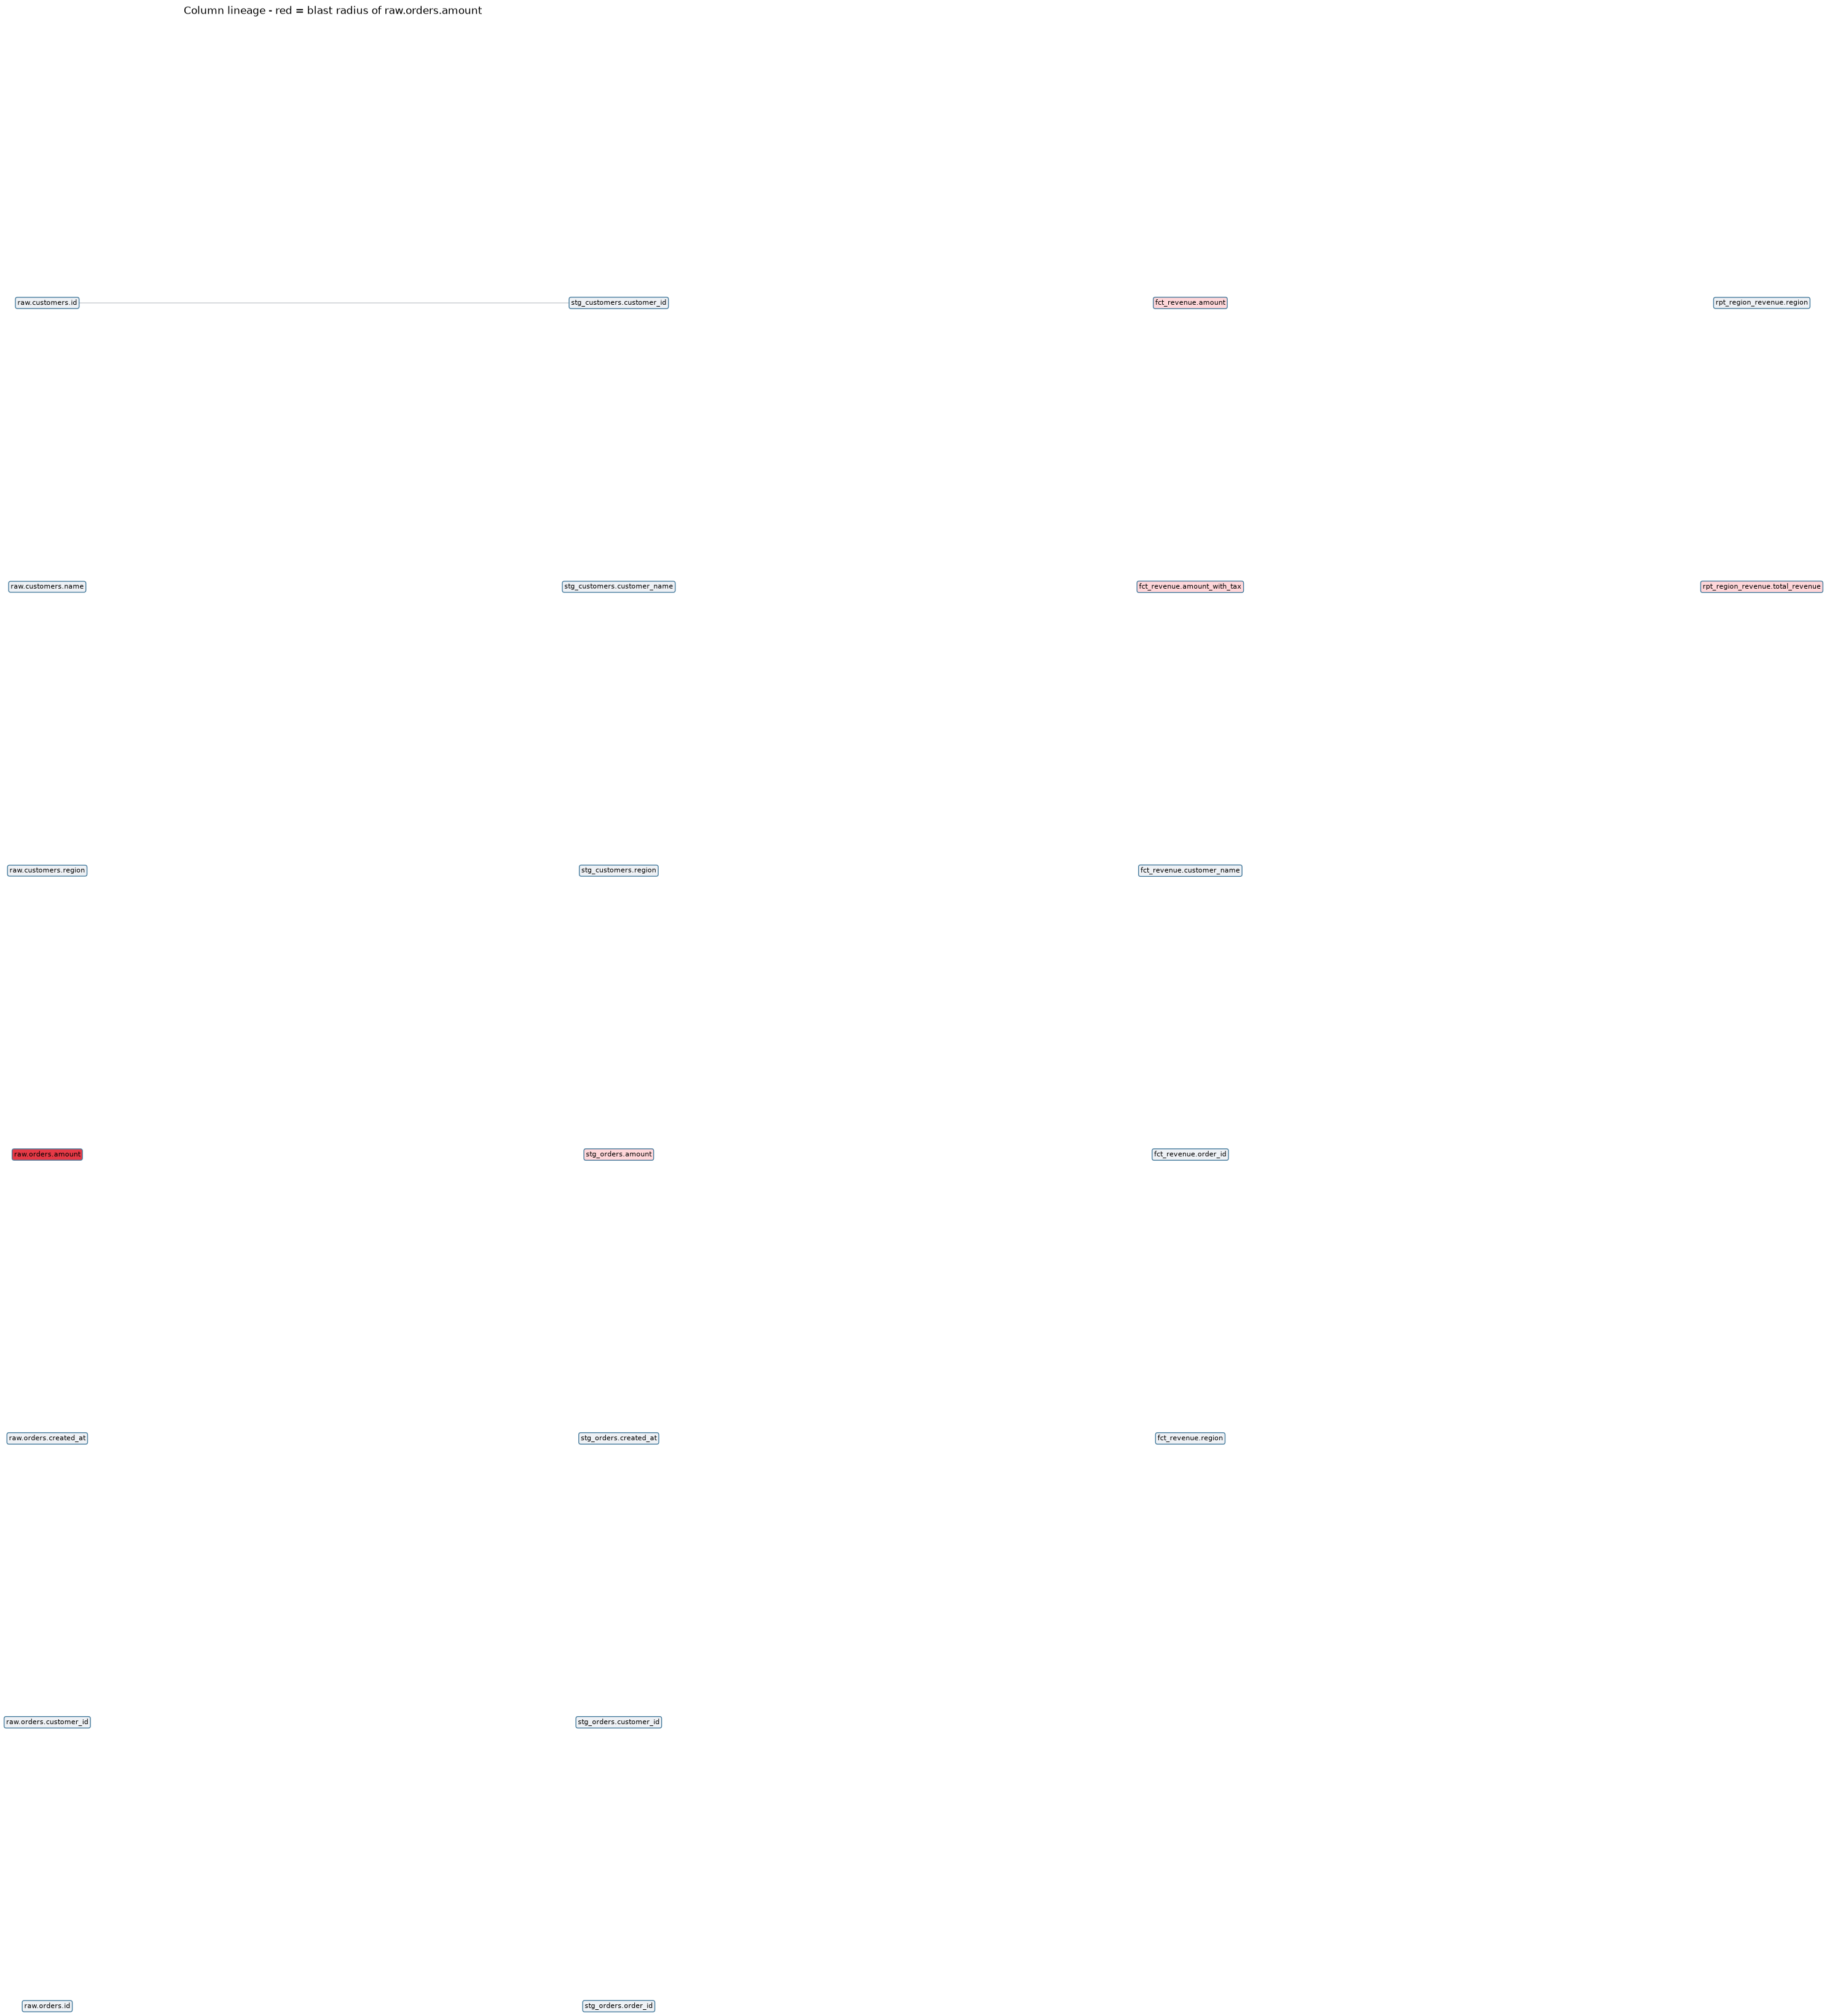

In [6]:
import matplotlib.pyplot as plt

picked = 'raw.orders.amount'
blast = set(lin.impact(picked))
nodes = sorted({e.source for e in lin.edges} | {e.target for e in lin.edges})

depth = {}
def _d(n, g):
    if n in depth: return depth[n]
    ps = [e.source for e in lin.edges if e.target == n]
    v = 0 if not ps else 1 + max((_d(p, g | {n}) for p in ps if p not in g), default=0)
    depth[n] = v; return v
for n in nodes: _d(n, set())

layers = {}
for n in nodes: layers.setdefault(depth[n], []).append(n)
pos = {}
for d, layer in layers.items():
    for j, n in enumerate(sorted(layer)): pos[n] = (d, -j)

fig, ax = plt.subplots(figsize=(12, 6))
for e in lin.edges:
    x1, y1 = pos[e.source]; x2, y2 = pos[e.target]
    hot = e.source == picked or e.target in blast
    ax.annotate('', xy=(x2 - 0.03, y2), xytext=(x1 + 0.03, y1),
                arrowprops=dict(arrowstyle='->', color='#e63946' if hot else '#c9ccd1',
                                lw=2 if hot else 1))
for n, (x, y) in pos.items():
    hot = n == picked or n in blast
    ax.text(x, y, n, ha='center', va='center', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3',
                      fc='#e63946' if n == picked else ('#ffd6d9' if hot else '#eef1f5'),
                      ec='#457b9d', lw=1))
ax.axis('off')
ax.set_title('Column lineage - red = blast radius of raw.orders.amount', fontsize=12)
fig.tight_layout()
fig.savefig('lineage_graph.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary

| Question | Method | Sample answer |
|---|---|---|
| Where does a number come from? | `upstream_of` | `total_revenue` ← `fct_revenue.amount_with_tax` |
| What breaks if I change this? | `impact` (transitive) | `raw.orders.amount` → 4 columns |
| Draw the map | depth layout + matplotlib | graph above |

Pure-Python, ~200 lines, runs anywhere. Point it at your dbt `models/` folder and you have column-level impact analysis in CI - no warehouse round-trip.

## 6. Try your own SQL

In [7]:
# my_models = {
#     'my_staging': '''CREATE TABLE my_staging AS
#         SELECT a.id AS id, a.value * 2 AS doubled
#         FROM raw.thing a''',
#     'my_report': '''CREATE VIEW my_report AS
#         SELECT id AS id, sum(doubled) AS total
#         FROM my_staging GROUP BY id''',
# }
# my_lin = parse_models(my_models)
# for e in my_lin.edges: print(e.source, '->', e.target)
# print('Blast radius of raw.thing.value:', my_lin.impact('raw.thing.value'))

---
Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Phoebe's daily FDE build portfolio. For the interactive Streamlit version with editable SQL boxes and a live impact selector, run `streamlit run app.py` in the project folder.